In [1]:
## lgbm optimization
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn import ensemble
from sklearn.model_selection import cross_val_score
from bayes_opt import BayesianOptimization
import matplotlib.pyplot as plt
import seaborn as sns
## lgbm regression model 
import lightgbm as lgb
import pandas as pd
import numpy as np
import numpy as np
from sklearn.ensemble import *
from sklearn.metrics import *
from sklearn.model_selection import *
import pandas as pd
import pennylane as qml
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
# Sample training data
import lightgbm as lgb
import pandas as pd
import numpy as np
import pennylane as qml
from pennylane import numpy as np
from sklearn.svm import SVR

df=pd.read_csv('E:/nlaptop/quantum machine learning/bandgap prediction/dataset/2D electronic properties2.csv',encoding='ISO-8859–1')    
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y = df['Band gap ']

# defining target
x=df[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]

# Splitting the dataset into training and test set.  
from sklearn.model_selection import train_test_split  
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.06, random_state=2)  
  
#feature Scaling  
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler    
st_x= StandardScaler()    
x_train= st_x.fit_transform(x_train)    
x_test= st_x.transform(x_test)



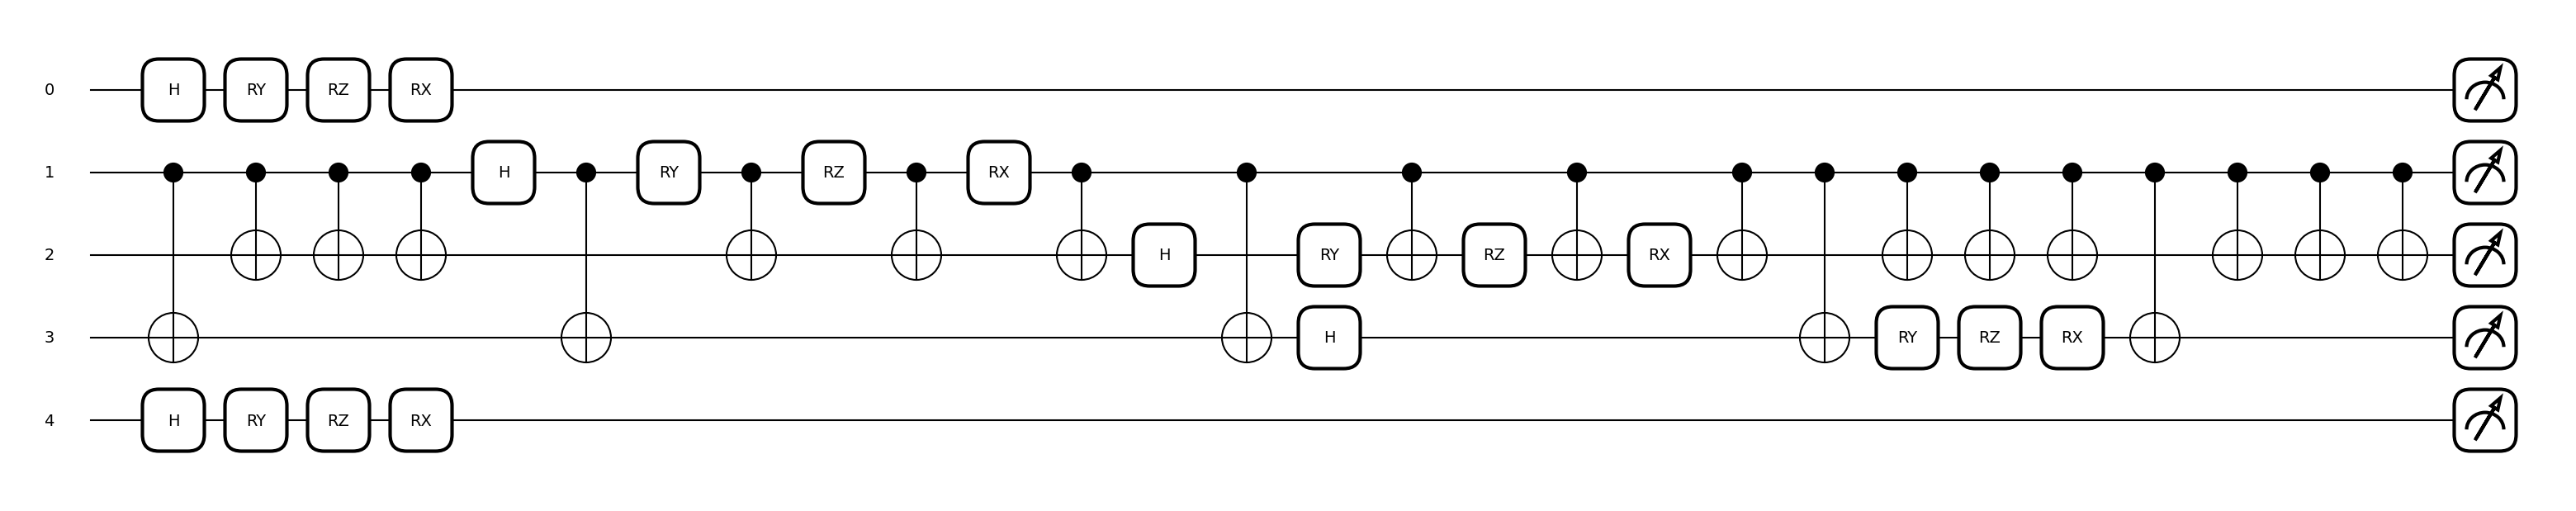

In [2]:
# Quantum setup
n_qubits = 5
dev = qml.device("default.qubit", wires=n_qubits)

# Define quantum feature map
def quantum_feature_map(x):
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
        qml.CNOT(wires=[1, 3])
        qml.RY(np.pi,wires=i)
        qml.CNOT(wires=[1, 2])
        qml.RZ(x[i % len(x)], wires=i)
        qml.CNOT(wires=[1, 2])
        qml.RX(np.pi*1.5, wires=i)
        qml.CNOT(wires=[1, 2])

# Define a quantum node
@qml.qnode(dev)
def circuit(x):
    quantum_feature_map(x)
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

# Visualize the quantum circuit for a sample
sample_x = x_train[0][:n_qubits]  # Take the first training sample, limit to `n_qubits`

# Draw the circuit using matplotlib
fig, ax = qml.draw_mpl(circuit)(sample_x)
plt.show()


In [3]:
# Quantum kernel function
@qml.qnode(dev)
def quantum_kernel(x1, x2):
    quantum_feature_map(x1)
    qml.adjoint(quantum_feature_map)(x2)
    return qml.probs(wires=range(n_qubits))
# Compute the kernel matrix for input data
def compute_kernel_matrix(X):
    n_samples = len(X)
    kernel_matrix = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        for j in range(n_samples):
            # Directly access the probability value (first element)
            kernel_matrix[i, j] = quantum_kernel(X[i], X[j])[0]
    return kernel_matrix
# Compute the quantum kernel matrix for training
K_train = compute_kernel_matrix(x_train)



In [4]:
import numpy as np
from skopt import gp_minimize
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor  # Example model, replace with your own
import lightgbm as lgb
# import ridge regression from sklearn library
from sklearn.linear_model import Ridge
# Define the objective function you want to optimize
def objective_function(x):
    # Instantiate the model with hyperparameters to be optimized
    model =SVR(kernel='precomputed', epsilon=float(x[0]),C=int(x[1]),gamma=int(x[2]))
    
    # Perform cross-validation and return the mean score
    return -np.mean(cross_val_score(model, K_train, y_train, cv=23, scoring='neg_root_mean_squared_error'))

# Perform Bayesian optimization
results = gp_minimize(objective_function, [(0.0001, 10),(10,1000),(0.0001,100)], n_calls=100)

# Extract the negative mean squared error values from the results
neg_root_mean_squared_error = results.func_vals

C:\Users\nepal\AppData\Roaming\Python\Python310\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [0.0001, 1000, 0.0001] before, using random point [0.9171305657695998, 18, 89.6815041959337]
  warnings.warn(
C:\Users\nepal\AppData\Roaming\Python\Python310\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [0.0001, 1000, 0.0001] before, using random point [7.691008067442977, 167, 75.92099200648141]
  warnings.warn(
C:\Users\nepal\AppData\Roaming\Python\Python310\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [0.0001, 1000, 0.0001] before, using random point [3.1617194325980136, 378, 25.61469573643767]
  warnings.warn(
C:\Users\nepal\AppData\Roaming\Python\Python310\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [0.0001, 1000, 0.0001] before, using random point [7.6886057754

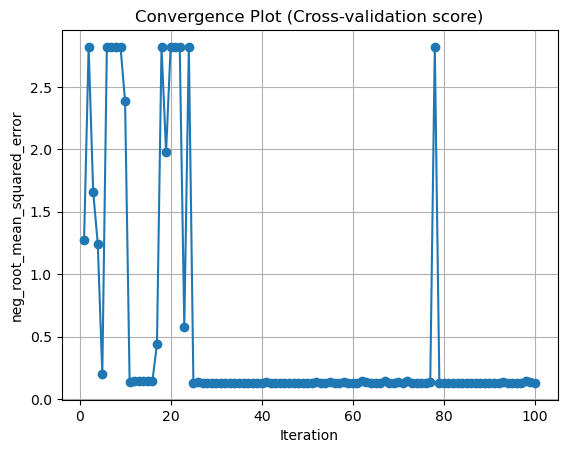

Best hyperparameters found:
epsilon: 0.07491851902055541
C: 977
gamma: 2.0881963569756823
Minimum rmse: 0.1285777883656568
Iteration Number: 27


In [5]:
# Plot the convergence
import matplotlib.pyplot as plt

iteration_numbers = np.arange(1, len(neg_root_mean_squared_error) + 1)
plt.plot(iteration_numbers, neg_root_mean_squared_error, marker='o')
plt.xlabel('Iteration')
plt.ylabel('neg_root_mean_squared_error')
plt.title('Convergence Plot (Cross-validation score)')
plt.grid(True)
plt.show()
# Extract best hyperparameters
best_params = results.x
print("Best hyperparameters found:")
print("epsilon:", best_params[0])
print("C:", best_params[1])
print("gamma:", best_params[2])
# Print minimum MSE found
# Find the index of the minimum MAE in the results
best_iteration_index = np.argmin(results.func_vals)


## 
# Find the index of the minimum MAE in the results
min_rmse_index = np.argmin(results.func_vals)

# Extract the minimum MAE and its corresponding iteration number
min_rmse = results.func_vals[min_rmse_index]
iteration_number = min_rmse_index + 1  # Adding 1 because iteration numbers start from 1

# Print the minimum MAE and its iteration number
print("Minimum rmse:", min_rmse)
print("Iteration Number:", iteration_number)

In [6]:
# Extracting n_estimators and max_features from the results
epsilon= [x[0] for x in results.x_iters]
C = [x[1] for x in results.x_iters]
gamma =   [x[2] for x in results.x_iters]

# Creating the DataFrame
df = pd.DataFrame({
    'iteration_numbers': iteration_numbers,
    'neg_root_mean_squared_error': neg_root_mean_squared_error,
    'epsilon': epsilon,
    'C': C,
    'gamma': gamma,
   })
df
df.to_csv('E:/nlaptop/quantum machine learning/bandgap prediction/quantum feature mapping/ranom state-2 testsize-6/qsvr optimization/CV-23 qsvr.csv')

In [10]:
# Train the SVR with a precomputed kernel matrix
svr = SVR(kernel='precomputed', epsilon=0.07491851902055541,C=977,gamma=2.0881963569756823)
svr.fit(K_train, y_train)

# Sample test data



# Compute the test kernel matrix (train-test kernel)
K_test = np.zeros((len(x_test), len(x_train)))
for i in range(len(x_test)):
    for j in range(len(x_train)):
        K_test[i, j] = quantum_kernel(x_test[i], x_train[j])[0]

# Predict using the trained model
y_pred = svr.predict(K_test)
print("Predicted values:", y_pred)

Predicted values: [0.68978842 0.09141466 1.22805237 2.88536068 4.46369899 4.6862489
 0.46895636 3.51777642 1.06260591 1.82082346 0.99390827 2.05606682
 2.5459754  2.21058401 0.75216345 0.07652835 3.17711267 3.91905554
 0.54598925 2.08565773 1.178765   2.38910804 0.13171374 1.78368021
 0.99055044 1.76673304 1.92447084 1.78588012 0.99181848 0.4696868
 0.27047118 3.12003539 0.30132626 0.4997455  2.91916609 1.94124339
 1.544427   2.86396879 0.53174484 0.6095811  0.99413754 5.5934849
 0.28905991 2.02036373 1.48070006 3.3951377  0.58246394 0.9538676
 1.63494036 0.12783946 0.57210997 3.99766552 2.14453593 4.07908937
 1.43746798 2.55039149 0.7096641  2.70018354 1.37412109 0.91953276
 0.53819853 1.45986775 0.24978236 3.78389912 2.05880993 0.38817841
 0.3187583  1.42015994 3.74381836 2.94824608 1.72943634 1.90452591
 0.75390238 1.21481136 1.30703248 3.52288523 2.29643611 4.57841652
 0.26126171 0.6614848  0.50913936 4.46339156 1.30330051 1.14792692
 4.41545059]


train r^2: 0.9925680132757904
train MAE 0.062322445546435415
train RMSE: 0.1219484208261961


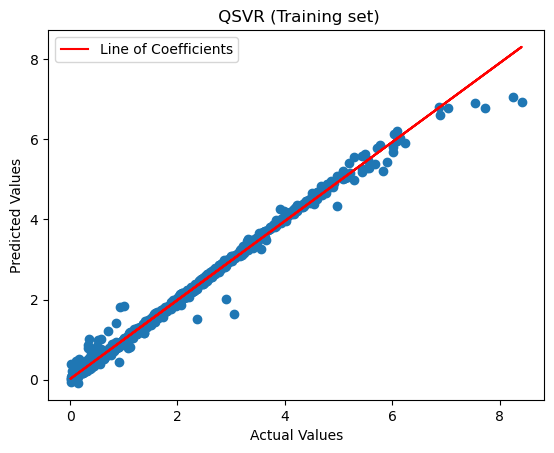

In [11]:
y_predtrain= svr.predict(K_train)
import numpy as np
from sklearn.ensemble import *
from sklearn.metrics import *
from sklearn.model_selection import *
import pandas as pd
## lgbm optimization
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn import ensemble
from sklearn.model_selection import cross_val_score
from bayes_opt import BayesianOptimization
import matplotlib.pyplot as plt
print('train r^2:',r2_score(y_train,y_predtrain))
print('train MAE', mean_absolute_error(y_train,y_predtrain))
print('train RMSE:',np.sqrt(mean_squared_error(y_train,y_predtrain)))
# Plot straight line
plt.scatter(y_train,y_predtrain)
coefficients = np.polyfit(y_train,y_predtrain, 1)
line = np.polyval(coefficients, y_train)
plt.plot(y_train, line, color='r', label='Line of Coefficients')
# Plot straight line
plt.plot(y_train, line, color='r',)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y_train,y_predtrain)), (-0.2, 20.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y_train,y_predtrain)), (-0.2, 18.2))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y_train,y_predtrain))), (-0.2, 16.0))
plt.title(" QSVR (Training set)")#title
plt.legend()

Model evaluation - Test Set:
r^2: 0.9972913922206673
RSE 0.00460920422111827
RAE 0.05499718665680843
RMSE: 0.06789112034072106


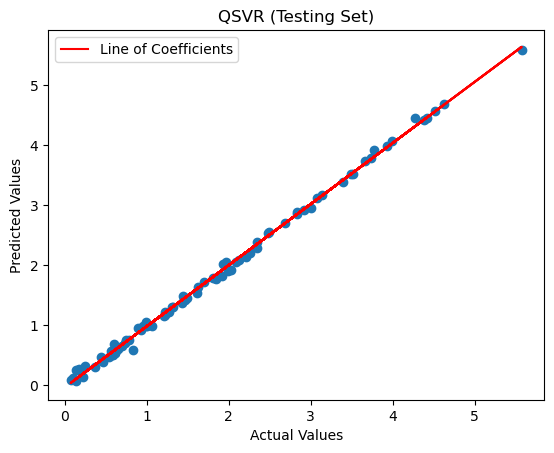

In [12]:
import numpy as np
from sklearn.ensemble import *
from sklearn.metrics import *
from sklearn.model_selection import *
import pandas as pd
## lgbm optimization
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn import ensemble
from sklearn.model_selection import cross_val_score
from bayes_opt import BayesianOptimization
import matplotlib.pyplot as plt
print("Model evaluation - Test Set:")
print('r^2:',r2_score(y_test, y_pred))
print('RSE', mean_squared_error(y_test, y_pred))
print('RAE', mean_absolute_error(y_test, y_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test, y_pred)))
# Plot straight line
plt.scatter(y_test, y_pred)
coefficients = np.polyfit(y_test, y_pred, 1)
line = np.polyval(coefficients, y_test)
plt.plot(y_test, line, color='r', label='Line of Coefficients')
# Plot straight line
plt.plot(y_test, line, color='r',)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y_test, y_pred)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y_test, y_pred))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y_test, y_pred)), (-0.2, 13.2))
plt.title("QSVR (Testing Set)")#title
plt.legend()